## Name:Shah Hetvi Ileshkumar

 ## project:1-  Insurance Claim Amount using Random Forest Regressor Projects

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,56,female,29.3,2,no,northwest,8344.10
1,46,male,34.4,0,no,northeast,10379.24
2,32,female,27.3,4,yes,southeast,26659.48
3,60,male,34.7,0,no,northwest,13005.19
4,25,male,36.3,1,no,northeast,8734.44
...,...,...,...,...,...,...,...
195,49,female,28.3,2,yes,southwest,25810.47
196,49,male,31.8,0,yes,southwest,26559.96
197,41,female,23.4,1,no,southwest,7615.20
198,58,female,32.0,2,yes,northwest,24383.46


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,56,female,29.3,2,no,northwest,8344.10
1,46,male,34.4,0,no,northeast,10379.24
2,32,female,27.3,4,yes,southeast,26659.48
3,60,male,34.7,0,no,northwest,13005.19
4,25,male,36.3,1,no,northeast,8734.44


In [5]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
195,49,female,28.3,2,yes,southwest,25810.47
196,49,male,31.8,0,yes,southwest,26559.96
197,41,female,23.4,1,no,southwest,7615.20
198,58,female,32.0,2,yes,northwest,24383.46
199,29,female,29.5,1,no,northeast,9117.80


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,200.0,41.5700,13.715527,18.00,30.0000,42.000,54.0000,64.00
bmi,200.0,31.0055,5.923585,17.50,27.2000,30.800,35.3250,44.30
children,200.0,1.9050,1.426939,0.00,1.0000,2.000,3.0000,4.00
charges,200.0,14327.4177,6871.402854,3898.38,9616.9425,12011.105,14942.3025,31572.22


In [7]:
df.shape

(200, 7)

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
le = LabelEncoder()

In [10]:
df['sex'] = le.fit_transform(df['sex'])

In [11]:
df['smoker'] = le.fit_transform(df['smoker'])

In [12]:
df['region']=le.fit_transform(df['region'])

In [13]:
x = df.drop("charges", axis=1)
y = df["charges"]

In [14]:
x

,age,sex,bmi,children,smoker,region
0,56,0,29.3,2,0,1
1,46,1,34.4,0,0,0
2,32,0,27.3,4,1,2
3,60,1,34.7,0,0,1
4,25,1,36.3,1,0,0
...,...,...,...,...,...,...
195,49,0,28.3,2,1,3
196,49,1,31.8,0,1,3
197,41,0,23.4,1,0,3
198,58,0,32.0,2,1,1


In [15]:
y

0       8344.10
1      10379.24
2      26659.48
3      13005.19
4       8734.44
         ...   
195    25810.47
196    26559.96
197     7615.20
198    24383.46
199     9117.80
Name: charges, Length: 200, dtype: float64

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
model=RandomForestRegressor(n_estimators=100)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred=model.predict(x_test)

In [20]:
y_pred

array([12321.9645,  9458.4507, 12195.9624, 10366.5825,  8897.9068,
        8090.3935, 14086.6773, 13575.5764, 10452.3896, 10486.4976,
       12436.2185, 11726.5684, 10769.0557,  7747.2531,  8017.4701,
       14592.3651, 11767.3771,  9032.242 , 12126.5999,  7513.3863,
       11020.544 , 27926.8963, 11664.1388,  7249.7291,  7317.1164,
       10859.7441, 11522.2586, 27244.4678, 25432.6317,  7284.4147,
        9658.029 ,  7227.034 , 11323.4116,  7919.9692, 12359.7231,
        9326.0218,  7903.6465, 11929.1347,  8381.6438,  8118.9722])

In [22]:
r2=r2_score(y_test, y_pred)
r2

0.840479662202003

In [24]:
mse=mean_squared_error(y_test, y_pred)
mse

4530540.245892366

In [25]:
importances = model.feature_importances_
features = x.columns
features

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='str')

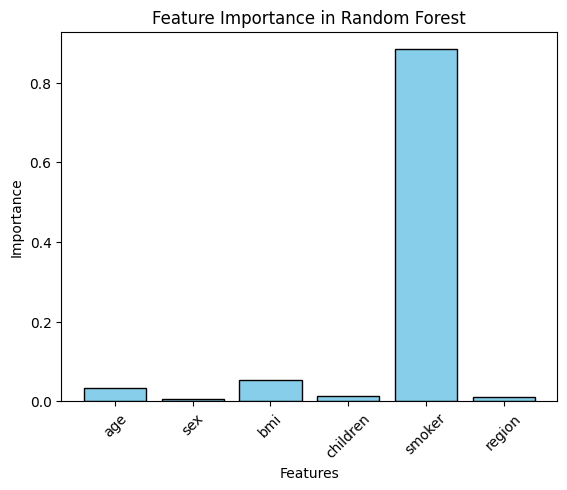

In [29]:
plt.bar(features, importances,color='skyblue',ec='black')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest")
plt.xticks(rotation=45)
plt.show()